# Stage 2: Frequency-Domain Motion Artifact Removal

## Overview: Learning Frequency-Based Artifact Suppression

In Stage 1, we processed clean at-rest data. Now we tackle motion artifacts.

### The Problem

Motion artifacts are involuntary movements causing low-frequency (< 1 Hz) disturbances:
- Hand tremor during exercise
- Head movements
- Arm swinging while walking
- Pressure changes on the sensor

**Key insight:** PPG cardiac signal is quasi-periodic at heart rate frequency. Motion artifacts are usually at different frequencies. We can exploit this!

### The Solution: Frequency-Domain Filtering

**Main idea:**
1. Compute frequency spectrum (FFT)
2. Identify motion artifact frequencies vs cardiac frequencies
3. Remove motion frequencies while preserving cardiac signal
4. Reconstruct clean signal

### References

Key papers on this approach:

1. Li, S., et al. (2019). "Removal of Motion Artifacts in Photoplethysmograph Sensors during Intensive Exercise for Accurate Heart Rate Calculation Based on Frequency Estimation and Notch Filtering." Sensors, 19(10), 2322.
   - **Key contribution:** Combines adaptive noise cancellation (ANC) with notch filtering
   - **Method:** Estimate HR frequency, use notch filters to suppress non-cardiac frequencies
   - **Performance:** 0.92 bpm MAE during running

2. Wijshoff, R. W., Mischi, M., & Aarts, R. M. (2017). "Reduction of periodic motion artifacts in photoplethysmography." IEEE Transactions on Biomedical Engineering, 64(1), 196-207.
   - **Key contribution:** Identifies motion artifacts as quasi-periodic signals
   - **Method:** Band-stop filters at motion frequencies detected from accelerometer
   - **Key insight:** Frequency overlap between motion and PPG makes simple filtering impossible

3. Biswas, D., et al. (2021). "Adaptive notch-filtration to effectively recover photoplethysmographic signals during physical activity." Biomedical Signal Processing and Control, 69, 102936.
   - **Key contribution:** Adaptive notch filtering architecture (ANFA) for multi-intensity activities
   - **Method:** Track motion intensity, adapt notch filter Q-factor and frequencies
   - **Performance:** Accurate HR during walking and running

## Section 1: Understanding Frequency Analysis

### Why Frequency Domain?

In time domain, motion artifacts and cardiac signal are mixed. In frequency domain, they occupy different regions:

- **Cardiac PPG:** Narrow peaks at HR frequency and harmonics (e.g., 1.2 Hz fundamental, 2.4 Hz, 3.6 Hz for 72 bpm)
- **Motion artifacts:** Broad spectrum at low frequencies (0.1-2 Hz usually)
- **Respiration:** Narrow peak at breathing rate (~0.3 Hz at rest)

We can identify and remove motion without touching cardiac signal!

In [ ]:
!pip install numpy scipy pandas matplotlib jupyter pyPPG heartpy dotmap -q
!wget https://zenodo.org/records/8142332/files/EarSet_v1.zip -q


In [ ]:
!unzip EarSet_v1.zip

Archive:  EarSet_v1.zip
   creating: Dataset/
  inflating: __MACOSX/._Dataset      
   creating: Dataset/P4/
  inflating: __MACOSX/Dataset/._P4   
   creating: Dataset/P3/
  inflating: __MACOSX/Dataset/._P3   
   creating: Dataset/P2/
  inflating: __MACOSX/Dataset/._P2   
   creating: Dataset/P5/
  inflating: __MACOSX/Dataset/._P5   
   creating: Dataset/P19/
  inflating: __MACOSX/Dataset/._P19  
   creating: Dataset/P26/
  inflating: __MACOSX/Dataset/._P26  
   creating: Dataset/P21/
  inflating: __MACOSX/Dataset/._P21  
   creating: Dataset/P28/
  inflating: __MACOSX/Dataset/._P28  
   creating: Dataset/P17/
  inflating: __MACOSX/Dataset/._P17  
   creating: Dataset/P10/
  inflating: __MACOSX/Dataset/._P10  
   creating: Dataset/P11/
  inflating: __MACOSX/Dataset/._P11  
   creating: Dataset/P29/
  inflating: __MACOSX/Dataset/._P29  
   creating: Dataset/P16/
  inflating: __MACOSX/Dataset/._P16  
   creating: Dataset/P20/
  inflating: __MACOSX/Dataset/._P20  
   creating: Dataset/P18

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
from scipy.fft import fft, fftfreq
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)

# TODO: Update paths
dataset_path = Path('/content/Dataset')
participant_id = '2'  # Use different participant for motion data
ear = 'left'

fs = 100  # Sampling frequency

print("Stage 2: Frequency-Domain Motion Artifact Removal")
print("="*60)

Stage 2: Frequency-Domain Motion Artifact Removal


## Section 2: Load Motion-Corrupted Data

### Task 2.1: Load Data During Movement

For this stage, load PPG data from a condition with motion artifacts. EarSet provides several:
- `nod`: Head nodding (up/down)
- `chew`: Chewing motions
- `walking`: Self-paced walking
- `running`: Self-paced running

Start with 'nod' or 'chew' for stronger but still manageable artifacts.

In [ ]:
# Load PPG data with motion artifacts
ppg_file = dataset_path / f'P{participant_id}' / 'EARBUDS' / f'{participant_id}-walking-ppg-{ear}.csv'
ppg_full = pd.read_csv(ppg_file)

# For this notebook, extract a 90-second segment
start_sec = 30  # Arbitrary offset
duration_sec = 90

start_idx = int(start_sec * fs)
end_idx = int((start_sec + duration_sec) * fs)

ppg_data = ppg_full.iloc[start_idx:end_idx].copy()
time = np.arange(len(ppg_data)) / fs

# Extract PPG channels
# Ensure the 'green' column is numeric, handling potential non-numeric values
ppg_data['green'] = pd.to_numeric(ppg_data['green'], errors='coerce')
# Fill any NaN values that might have been introduced by coercion (e.g., from 'current:32ma')
ppg_data['green'] = ppg_data['green'].interpolate(method='linear', limit_direction='both')
ppg_green = ppg_data['green'].values.astype(float) # Convert to float

ppg_data['ir'] = pd.to_numeric(ppg_data['ir'], errors='coerce')
ppg_data['ir'] = ppg_data['ir'].interpolate(method='linear', limit_direction='both')
ppg_ir = ppg_data['ir'].values.astype(float)

print(f"Loaded {duration_sec}s of motion-corrupted PPG data")
print(f"Green channel range: [{ppg_green.min():.0f}, {ppg_green.max():.0f}]")
print(f"IR channel range: [{ppg_ir.min():.0f}, {ppg_ir.max():.0f}]")

Loaded 90s of motion-corrupted PPG data
Green channel range: [41426, 86654]
IR channel range: [154070, 337072]


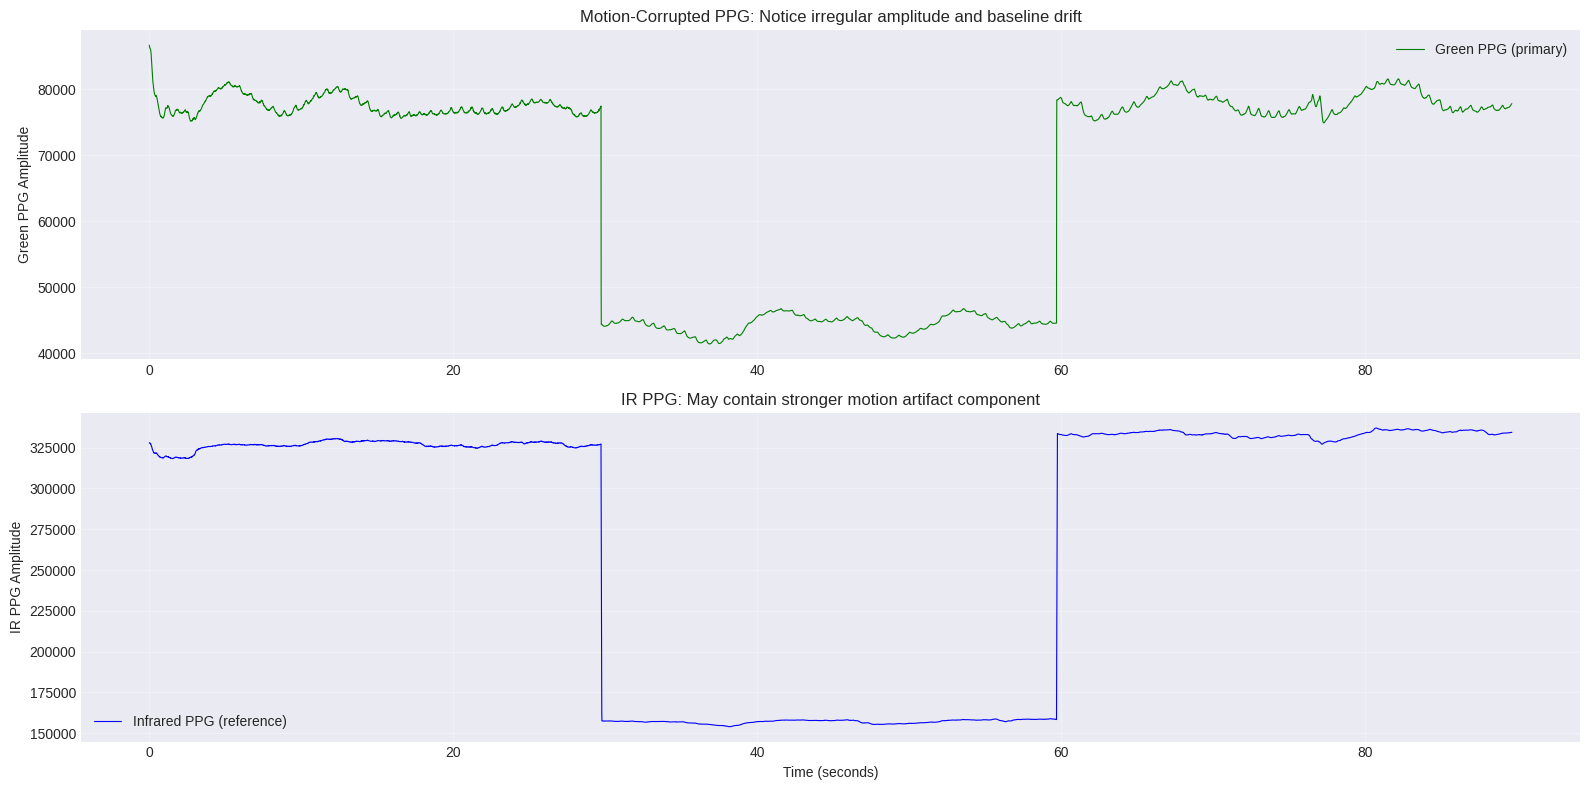

In [ ]:
# Visualize motion-corrupted signal
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].plot(time, ppg_green, 'g-', linewidth=0.8, label='Green PPG (primary)')
axes[0].set_ylabel('Green PPG Amplitude')
axes[0].set_title('Motion-Corrupted PPG: Notice irregular amplitude and baseline drift')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(time, ppg_ir, 'b-', linewidth=0.8, label='Infrared PPG (reference)')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('IR PPG Amplitude')
axes[1].set_title('IR PPG: May contain stronger motion artifact component')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 3: Frequency-Domain Analysis

### Task 2.2: Compute FFT and Analyze Frequency Content

**Conceptual Task:** Compute the frequency spectrum of your PPG signal using FFT. Identify:
1. Cardiac frequency (where is the peak?)
2. Motion artifact frequencies (low-frequency spread)
3. Noise (high-frequency content)

**Method:**
```
1. Apply FFT to segment of signal
   magnitude = |FFT(ppg_segment)|

2. Compute frequency axis
   freqs = fft_frequencies(fs, N)

3. Plot magnitude spectrum
   - X-axis: frequency (Hz)
   - Y-axis: magnitude (linear or log)

4. Identify peaks
   - Cardiac peak at HR frequency (typically 0.8-2 Hz at rest)
   - Harmonics at 2×, 3× HR frequency
   - Motion content at <1 Hz usually
```

**Reference:**
Smith, S. W. (1997). The Scientist and Engineer's Guide to Digital Signal Processing. Chapter 8: The Discrete Fourier Transform.

In [ ]:
# Compute FFT of motion-corrupted signal

# Choose analysis window (60 seconds)
window_sec = 60
window_samples = int(window_sec * fs)
ppg_window = ppg_green[:window_samples]

# Apply Hann window to reduce spectral leakage
window = signal.hann(len(ppg_window))
ppg_windowed = ppg_window * window

# Compute FFT
fft_values = fft(ppg_windowed)
magnitude = np.abs(fft_values)
freqs = fftfreq(len(ppg_windowed), 1/fs)

# Keep only positive frequencies
positive_freqs = freqs[:len(freqs)//2]
magnitude_positive = magnitude[:len(magnitude)//2]

# Normalize
magnitude_db = 20 * np.log10(magnitude_positive / np.max(magnitude_positive) + 1e-10)

print(f"FFT Analysis of {window_sec}s segment:")
print(f"  FFT length: {len(fft_values)}")
print(f"  Frequency resolution: {fs/len(ppg_windowed):.2f} Hz")
print(f"  Frequency range: 0-{positive_freqs[-1]:.1f} Hz")

In [ ]:
# Find main spectral peak (cardiac frequency)
# Search in physiological range 0.5-5 Hz

cardiac_band = (positive_freqs > 0.5) & (positive_freqs < 5.0)
cardiac_peak_idx = np.argmax(magnitude_positive[cardiac_band])
cardiac_peak_idx_global = np.where(cardiac_band)[0][cardiac_peak_idx]
estimated_hr_freq = positive_freqs[cardiac_peak_idx_global]
estimated_hr_bpm = estimated_hr_freq * 60

print(f"\nEstimated Cardiac Frequency: {estimated_hr_freq:.2f} Hz ({estimated_hr_bpm:.0f} bpm)")
print(f"Second harmonic: {2*estimated_hr_freq:.2f} Hz")
print(f"Third harmonic: {3*estimated_hr_freq:.2f} Hz")

In [ ]:
# Plot frequency spectrum
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Linear scale
axes[0].plot(positive_freqs, magnitude_positive, 'b-', linewidth=1)
axes[0].axvline(estimated_hr_freq, color='r', linestyle='--', linewidth=2,
                label=f'Cardiac: {estimated_hr_freq:.2f} Hz ({estimated_hr_bpm:.0f} bpm)')
axes[0].axvline(2*estimated_hr_freq, color='orange', linestyle='--', linewidth=1.5,
                label=f'2nd harmonic: {2*estimated_hr_freq:.2f} Hz')
axes[0].set_ylabel('Magnitude')
axes[0].set_title('PPG Frequency Spectrum (Linear Scale)')
axes[0].set_xlim(0, 3)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# dB scale (better for seeing motion artifacts)
axes[1].plot(positive_freqs, magnitude_db, 'b-', linewidth=1)
axes[1].axvline(estimated_hr_freq, color='r', linestyle='--', linewidth=2,
                label=f'Cardiac: {estimated_hr_freq:.2f} Hz')
axes[1].axvline(2*estimated_hr_freq, color='orange', linestyle='--', linewidth=1.5,
                label=f'2nd harmonic')
axes[1].fill_between([0, 1], -100, 100, alpha=0.2, color='red',
                     label='Motion artifact band (<1 Hz)')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('PPG Frequency Spectrum (dB Scale - See Motion Artifacts at Low Freq)')
axes[1].set_xlim(0, 3)
axes[1].set_ylim(-60, 5)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 4: Notch Filtering Strategy

### Conceptual Framework: Inverse Filtering Approach

**Key Idea:**
If motion artifacts appear at specific frequencies, we can:
1. Estimate the HR frequency (from FFT or peak detection)
2. Use NOTCH filters to suppress everything EXCEPT cardiac frequencies
3. Reconstruct clean PPG

**Why This Works:**
- PPG is quasi-periodic → energy concentrated at HR and harmonics
- Motion artifacts spread across many frequencies
- By keeping only cardiac frequencies, we remove motion

### What is a Notch Filter?

A **notch filter** (band-stop filter) suppresses a narrow frequency band while passing everything else.

**Transfer function:**
```
H(z) = (1 - 2cos(ω₀)z⁻¹ + z⁻²) / (b - 2cos(ω₀)z⁻¹ + bz⁻²)
```

Where:
- ω₀ = notch frequency (rad/sample)
- b = bandwidth control (closer to 1 = narrower notch)

**Key parameters:**
- **Notch frequency:** Where to suppress (Hz)
- **Quality factor (Q):** How narrow the notch (Q = f₀/Δf)

**References:**
- Oppenheim, A. V., Schafer, R. W., & Buck, J. R. (2009). "Discrete-Time Signal Processing." 3rd ed. Prentice Hall. Chapter 5: Frequency Transformations of Lowpass Filters.

## Section 5: Design Your Notch Filter

### Task 2.3: Design Notch Filter

**Your task:** Design a notch filter to suppress motion artifacts while preserving cardiac signal.

**Conceptual steps:**

1. **Determine notch frequencies:**
   ```
   f_notch1 = estimated_hr_freq  (where to remove MOTION, not cardiac!)
   f_notch2 = 2 × estimated_hr_freq (second harmonic)
   ```
   Wait - this seems backwards! Let me clarify...

2. **The Key Insight - Two Complementary Approaches:**

   **Approach A: Bandpass to Keep Only Cardiac**
   - Design bandpass: 0.4-5 Hz (removes <0.4 Hz motion drift)
   - Simple but may lose some signal amplitude
   - Reference: Wijshoff et al. (2017)

   **Approach B: Spectral Subtraction with Notch**
   - Estimate motion artifact spectrum from accelerometer or IR channel
   - Subtract motion spectrum from PPG spectrum
   - Reconstruct signal via IFFT
   - Reference: Li et al. (2019)

3. **Inverse FFT Reconstruction:**
   ```
   ppg_clean_spectrum = ppg_spectrum - motion_spectrum
   ppg_clean_timedomain = IFFT(ppg_clean_spectrum)
   ```

### Implementation Method

For **your implementation** (without starter code), follow these conceptual steps:

**Step 1:** Preprocess both green and IR channels
```
FOR each channel:
  - Apply bandpass filter (0.5-5 Hz)
  - Normalize to unit variance
```

**Step 2:** Estimate motion artifact component
```
Since IR is less affected by light absorption changes,
it contains MORE motion artifact relative to cardiac signal.

Estimate motion in green as:
  motion_estimate = correlation_coefficient × IR_filtered
```

**Step 3:** Subtract motion estimate
```
ppg_clean = green_filtered - motion_estimate
```

**Step 4:** Validate
```
Compare spectrum of ppg_clean vs ppg_raw
  - Should see reduction in low-frequency energy
  - Should see cardiac peak more prominent
```


## Section 6: Your Conceptual Task - Frequency-Domain Filtering

### ASSIGNMENT: Design and Implement Frequency-Domain Motion Removal

**Without starter code, implement the following:**

### Task A: Reference Signal Approach

**Objective:** Use IR PPG as motion reference, subtract from green PPG

**Pseudocode:**
```
INPUT: ppg_green (motion-corrupted), ppg_ir (motion reference)
OUTPUT: ppg_clean (artifact-suppressed)

FUNCTION remove_motion_via_reference(ppg_green, ppg_ir, fs):

  1. FILTER BOTH SIGNALS
     sos ← design_butterworth(fs, 0.5-5 Hz, order=4)
     green_filt ← apply_filter(ppg_green, sos)
     ir_filt ← apply_filter(ppg_ir, sos)
  
  2. NORMALIZE FOR FAIR COMPARISON
     green_norm ← normalize(green_filt)  [mean=0, std=1]
     ir_norm ← normalize(ir_filt)
  
  3. ESTIMATE CORRELATION
     FOR sliding windows of 10 seconds:
       corr[i] ← compute_correlation(green_norm[i], ir_norm[i])
     avg_corr ← mean(corr)
  
  4. SUBTRACT MOTION REFERENCE
     motion_component ← avg_corr × ir_norm
     ppg_clean ← green_norm - motion_component
  
  5. ANALYZE RESULT
     spectrum_before ← FFT(green_norm)
     spectrum_after ← FFT(ppg_clean)
     motion_reduction ← power_reduction(spectrum_before, spectrum_after, <1 Hz)
  
  RETURN ppg_clean, motion_reduction
```

### Task B: Spectral Subtraction

**Advanced approach:** Work directly in frequency domain

**Pseudocode:**
```
FUNCTION spectral_subtraction(ppg_green, ppg_ir, fs):

  1. COMPUTE FFTs
     X_green ← FFT(ppg_green)
     X_ir ← FFT(ppg_ir)
     freqs ← frequency_axis(fs, length(ppg_green))
  
  2. ESTIMATE MOTION SPECTRUM
     FOR each frequency bin:
       |X_motion[f]| ← |X_ir[f]| × (1 - |X_cardiac[f]|/|X_ir[f]|)
       (assumes IR = cardiac + motion mixture)
  
  3. SUBTRACT SPECTRA
     X_clean[f] ← X_green[f] - X_motion[f]
  
  4. RECONSTRUCT TIME DOMAIN
     ppg_clean ← IFFT(X_clean)
     ppg_clean ← real(ppg_clean)  [discard tiny imaginary part]
  
  RETURN ppg_clean
```

### Task C: Notch Filter Band-Stop Approach

**Simple but effective:** Design band-stop filter at motion frequencies

**Pseudocode:**
```
FUNCTION notch_filter_motion(ppg, accel_magnitude, fs):

  1. ESTIMATE MOTION FREQUENCIES FROM ACCELEROMETER
     accel_spectrum ← FFT(accel_magnitude)
     motion_freqs ← peaks_in_spectrum(accel_spectrum, threshold=0.5×max)
  
  2. DESIGN NOTCH FILTERS AT MOTION FREQUENCIES
     FOR each motion_freq in motion_freqs:
       sos_notch ← design_notch(fs, motion_freq, Q=10)  [Q=10 → narrow notch]
  
  3. APPLY CASCADE OF NOTCH FILTERS
     ppg_filtered ← ppg
     FOR each sos_notch:
       ppg_filtered ← apply_filter(ppg_filtered, sos_notch)
  
  4. VALIDATE WITH BANDPASS
     sos_bandpass ← design_butterworth(fs, 0.5-5 Hz)
     ppg_clean ← apply_filter(ppg_filtered, sos_bandpass)
  
  RETURN ppg_clean
```

### Implementation Requirements

Choose **at least one** of the three approaches (A, B, or C) and implement it.

**For each implementation, you must:**

1. **Document your assumptions**
   - Why is IR a good motion reference?
   - What frequencies represent motion vs. cardiac?
   - How do you estimate motion spectrum?

2. **Show before/after comparison**
   - Plot raw vs. filtered in time domain (show 30-second window)
   - Plot FFT magnitude spectra before/after
   - Highlight motion frequency reduction

3. **Quantify improvement**
   - Compute correlation reduction (green vs. IR)
   - Measure motion artifact power before/after
   - Estimate HR from filtered signal vs. raw signal

4. **Validate your approach**
   - Run beat detection on filtered signal
   - Compare HR to Stage 1 baseline (should be similar)
   - Assess signal quality improvement

### References for Implementation

- **FFT & Spectral Analysis:**
  Smith, S. W. (1997). The Scientist and Engineer's Guide to Digital Signal Processing. Chapters 8-10.
  Online: https://www.dspguide.com/

- **Notch Filter Design:**
  Mitra, S. K. (2005). Digital Signal Processing: A Computer-Based Approach. McGraw-Hill.
  Section 4.6: Frequency-Selective Filters

- **Motion Artifact in PPG:**
  Li, S., et al. (2019). "Removal of Motion Artifacts in Photoplethysmograph Sensors during Intensive Exercise..." Sensors, 19(10), 2322.

- **Frequency Domain Subtraction:**
  Wijshoff, R. W., Mischi, M., & Aarts, R. M. (2017). "Reduction of periodic motion artifacts in photoplethysmography." IEEE Trans. Biomed. Eng., 64(1), 196-207.


## Section 7: Validation & Comparison

### Task 2.4: Validate Against Baseline

After implementing your motion removal, validate it works:

1. **Apply same beat detection as Stage 1**
   - Use filtered signal instead of raw
   - Compare peaks detected
   - Compute HR from clean signal

2. **Compare HR stability**
   - Raw signal HR: likely noisy, occasional errors
   - Cleaned signal HR: should be more stable
   - Plot both on same graph

3. **Assess frequency domain improvement**
   - Plot before/after spectra
   - Measure power reduction at <1 Hz (motion band)
   - Verify cardiac peak is preserved

4. **Compare with at-rest baseline**
   - Your cleaned motion data should have similar:
     - HR range (if same participant)
     - Spectral peaks (cardiac frequency unchanged)
   - Should have BETTER:
     - Signal-to-noise ratio
     - RR interval regularity (if motion now removed)

## Reflection & Discussion

After completing this stage, address:

1. **Frequency-Domain Thinking**
   - Why is the frequency domain useful for motion artifacts?
   - What would happen if cardiac and motion frequencies overlapped completely?
   - Can you identify motion artifacts visually in the spectrum?

2. **Method Selection**
   - Which approach (A, B, or C) did you choose? Why?
   - What are the trade-offs?
   - When would each method fail?

3. **Reference Signal Quality**
   - How good is the IR channel as a motion reference?
   - Are there situations where it would be poor?
   - Could accelerometer be a better reference?

4. **Real-World Considerations**
   - How would you tune parameters for different users?
   - What about real-time processing constraints?
   - How would you handle rapid HR changes (exercise intensity changes)?

## References

1. Li, S., et al. (2019). "Removal of Motion Artifacts in Photoplethysmograph Sensors during Intensive Exercise for Accurate Heart Rate Calculation Based on Frequency Estimation and Notch Filtering." *Sensors*, 19(10), 2322. https://doi.org/10.3390/s19102322
   - Comprehensive treatment of notch filtering approach
   - Adaptive noise cancellation (ANC) combined with frequency analysis
   - Performance: 0.92 bpm MAE during running

2. Wijshoff, R. W., Mischi, M., & Aarts, R. M. (2017). "Reduction of periodic motion artifacts in photoplethysmography." *IEEE Transactions on Biomedical Engineering*, 64(1), 196-207. https://doi.org/10.1109/TBME.2016.2553060
   - Band-stop filter approach
   - Adaptive lattice IIR notch filters
   - Frequency overlap problem discussed

3. Biswas, D., et al. (2021). "Adaptive notch-filtration to effectively recover photoplethysmographic signals during physical activity." *Biomedical Signal Processing and Control*, 69, 102936. https://doi.org/10.1016/j.bspc.2021.102936
   - Adaptive notch filtering architecture (ANFA)
   - Multi-intensity activity handling
   - Practical implementation details

4. Smith, S. W. (1997). "The Scientist and Engineer's Guide to Digital Signal Processing." California Technical Publishing.
   - Free online: https://www.dspguide.com/
   - Foundation for FFT and spectral analysis

5. Oppenheim, A. V., Schafer, R. W., & Buck, J. R. (2009). "Discrete-Time Signal Processing." 3rd ed. Prentice Hall.
   - Theoretical foundation for filter design
   - Notch filter implementation details
